In [37]:
import pandas as pd
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [42]:
# 1. Load the dataset
data = """email_text,label
"Win a free iPhone now click here",1
"Meeting scheduled for tomorrow at 10am",0
"Congratulations you have won a lottery claim now",1
"Please find attached project report",0
"Limited time offer buy now",1
"Lets catch up for lunch today",0
"Earn money from home no experience needed",1
"Your order has been shipped successfully",0
"Get cheap meds online without prescription",1
"Team meeting rescheduled to Friday",0
"Claim your free vacation package now",1
"Reminder for your doctor appointment",0
"You have been selected for a prize click here",1
"Monthly performance report attached",0
"Exclusive deal just for you hurry up",1
"Can you review this document",0
"Act now to win big rewards",1
"Family dinner this weekend",0
"Lowest prices guaranteed shop now",1
"Your bank statement is ready",0
"Click here to claim your reward",1
"Project deadline is next Monday",0
"Free entry in a contest win cash",1
"Lets have a quick call today",0
"Special promotion ends tonight",1
"Invoice for your recent purchase",0
"You won a free ticket click now",1
"Weekly team sync meeting notes",0
"Get rich quick scheme join now",1
"Your subscription has been renewed",0
"Earn dollars fast with this trick",1
"Please approve the leave request",0
"Hot deals available only today",1
"Schedule a meeting with client",0
"Claim bonus reward instantly",1
"Update your account information",0
"Win cash prizes easily click now",1
"Draft for review attached",0
"Limited offer hurry buy today",1
"Your package delivery update",0
"Free coupons available click here",1
"Team outing planned this weekend",0
"Double your income fast join now",1
"Please submit assignment by tonight",0
"Exclusive offer for valued customer",1
"Meeting agenda shared",0
"Congratulations you are a winner",1
"Feedback on your performance",0
"Click now to unlock premium features",1
"Reminder to complete your profile",0"""

In [45]:
# Load the dataset
df = pd.read_csv(StringIO(data))
df


,email_text,label
0,Win a free iPhone now click here,1
1,Meeting scheduled for tomorrow at 10am,0
2,Congratulations you have won a lottery claim now,1
3,Please find attached project report,0
4,Limited time offer buy now,1
5,Lets catch up for lunch today,0
6,Earn money from home no experience needed,1
7,Your order has been shipped successfully,0
8,Get cheap meds online without prescription,1
9,Team meeting rescheduled to Friday,0


C:\Users\E-TIME\AppData\Local\Temp\ipykernel_1724\304137836.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


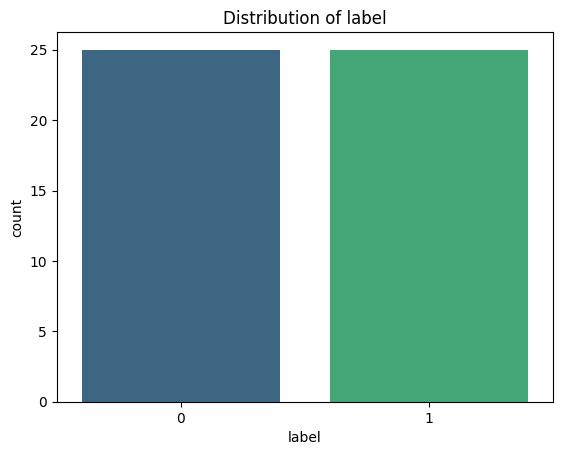

In [62]:
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of label')
plt.show()

In [46]:
# 2. Preprocessing & Feature Extraction
# Converting text to TF-IDF features
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df['email_text'])
y = df['label']

In [47]:
# 2. Preprocessing & Feature Extraction
# Converting text to TF-IDF features
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df['email_text'])
y = df['label']

In [48]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
# 4. Initialize and Train the Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [59]:
# 5. Make Predictions
y_pred = model.predict(X_test)

In [60]:
# 6. Evaluate the Model
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 70.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.57      1.00      0.73         4

    accuracy                           0.70        10
   macro avg       0.79      0.75      0.70        10
weighted avg       0.83      0.70      0.69        10



In [61]:
# 7. Test with a custom email
test_email = ["Urgent: You won $1000 cash, click this link to claim"]
test_vector = tfidf.transform(test_email)
prediction = model.predict(test_vector)

print(f"\nCustom Email: {test_email[0]}")
print(f"Prediction: {'Spam' if prediction[0] == 1 else 'Ham'}")


Custom Email: Urgent: You won $1000 cash, click this link to claim
Prediction: Spam


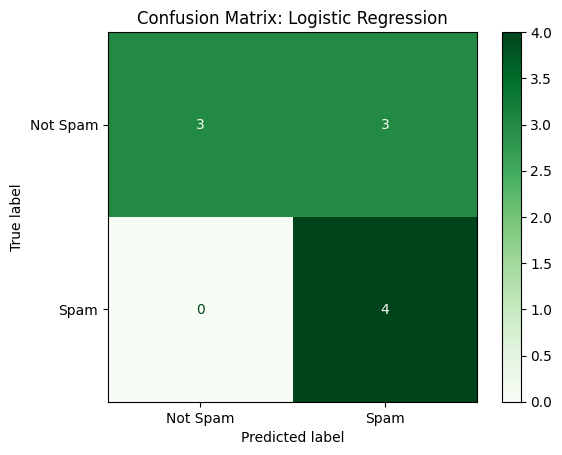

In [64]:
# Plot Confusion Matrix
from sklearn.metrics import confusion_matrix


cm_lr = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not Spam', 'Spam'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()